In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


dataset = ImageFolder(r'E:\TE\Project_TE_intern\New_research\Soybean Seeds', transform=transform)

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, val_size, test_size])

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

resnet_model = models.resnet50(pretrained=True)

for param in resnet_model.parameters():
    param.requires_grad = False
resnet_model.fc.requires_grad = True

num_classes = len(dataset.classes)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, num_classes)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet_model.fc.parameters(), lr=0.001)

num_epochs = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet_model.to(device)
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    resnet_model.train()
    running_train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = resnet_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)
    train_losses.append(train_loss)

    resnet_model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = resnet_model(images)
            val_loss += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    accuracy = 100 * correct / total
    print(f"Epoch [{epoch + 1}/{num_epochs}] - Validation Loss: {val_loss:.4f}, Accuracy: {accuracy:.2f}%")

resnet_model.eval()
test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = resnet_model(images)
        test_loss += criterion(outputs, labels).item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/10] - Validation Loss: 0.7230, Accuracy: 74.94%
Epoch [2/10] - Validation Loss: 0.5654, Accuracy: 80.87%
Epoch [3/10] - Validation Loss: 0.5198, Accuracy: 80.63%
Epoch [4/10] - Validation Loss: 0.5694, Accuracy: 78.45%
Epoch [5/10] - Validation Loss: 0.4732, Accuracy: 83.41%
Epoch [6/10] - Validation Loss: 0.5012, Accuracy: 80.39%
Epoch [7/10] - Validation Loss: 0.4394, Accuracy: 83.29%
Epoch [8/10] - Validation Loss: 0.4783, Accuracy: 82.81%
Epoch [9/10] - Validation Loss: 0.4388, Accuracy: 82.93%
Epoch [10/10] - Validation Loss: 0.4617, Accuracy: 81.72%
Test Accuracy: 81.40%


In [ ]:
h5_path = 'E:\\TE\\Project_TE_intern\\New_research\\Soybean Seeds\\resnet50_model_ori.h5'
torch.save(resnet_model.state_dict(), h5_path)
print(f"Model saved to {h5_path} in HDF5 (.h5) format")

Model saved to E:\TE\Project_TE_intern\New_research\Soybean Seeds\resnet50_model_ori.h5 in HDF5 (.h5) format


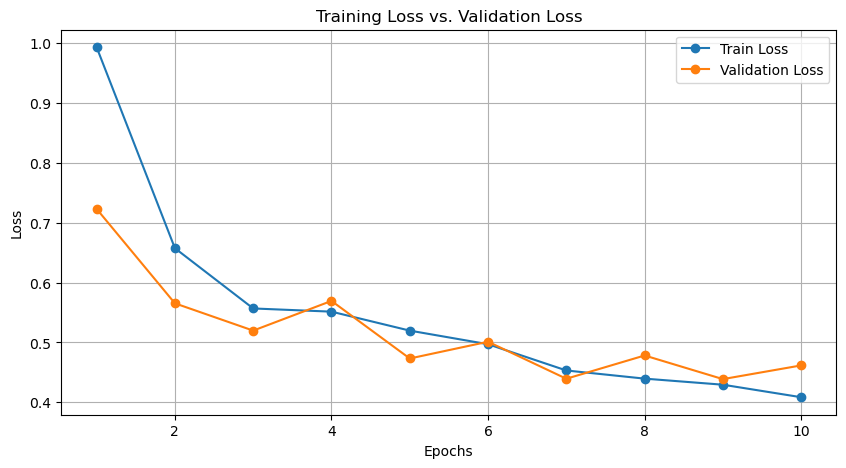

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.title('Training Loss vs. Validation Loss')
plt.show()

In [ ]:
import torch
import h5py
import torchvision.models as models
import torch.nn as nn
from torchvision import transforms
from PIL import Image

idx_to_class = {
    0: 'Broken soybeans',
    1: 'Immature soybeans',
    2: 'Intact soybeans',
    3: 'Skin-damaged soybeans',
    4: 'Spotted soybeans'
}

model = models.resnet50(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, len(dataset.classes))
model.load_state_dict(torch.load('E:\\TE\\Project_TE_intern\\New_research\\Soybean Seeds\\resnet50_model_ori.h5'))
model.to(device)
model.eval()

from torchvision import transforms
from PIL import Image
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def predict_image(image_path):
    image = Image.open(image_path)
    image = transform_test(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image)
        _, predicted_idx = torch.max(output, 1)
    predicted_label = idx_to_class[predicted_idx.item()]
    return predicted_label

image_path = "E:\\TE\\Project_TE_intern\\New_research\\Soybean Seeds\\Spotted soybeans\\95.jpg"
predicted_label = predict_image(image_path)
print(f"Predicted Label for {image_path}: {predicted_label}")

Predicted Label for E:\TE\Project_TE_intern\New_research\Soybean Seeds\Spotted soybeans\95.jpg: Spotted soybeans


In [ ]:
pip install lime

                                              0.0/275.7 kB ? eta -:--:--
     ------------------------------------   266.2/275.7 kB 8.0 MB/s eta 0:00:01
     -------------------------------------- 275.7/275.7 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283846 sha256=def7fefd541d2579efa264b4d3306b8ad2110f6af28d944bbf2cd7bd25263fff
  Stored in directory: c:\users\user\appdata\local\pip\cache\wheels\85\fa\a3\9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime
Note: you may need to restart the kernel to use updated packages.


C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Broken


  0%|          | 0/1000 [00:00<?, ?it/s]

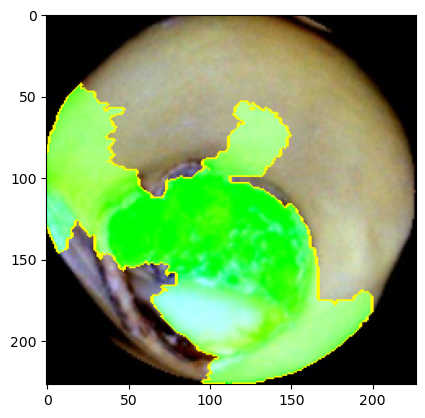

In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import numpy as np
import lime
from lime import lime_image
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt
import h5py

model = models.resnet50(pretrained=False)
num_classes = 5
model.fc = nn.Linear(model.fc.in_features, num_classes)

model.load_state_dict(torch.load('E:\\TE\\Project_TE_intern\\New_research\\Soybean Seeds\\resnet50_model_ori.h5'))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

idx_to_class = {
    0: 'Broken',
    1: 'Immature soybeans',
    2: 'Intact soybeans',
    3: 'Skin-damaged soybeans',
    4: 'Spotted soybeans'
}

def predict(images):
    model.eval()
    images = torch.stack([transform_test(Image.fromarray(image).convert('RGB')) for image in images]).to(device)
    with torch.no_grad():
        output = model(images)
    return output.cpu().numpy()

def explain_image(image_path):
    image = Image.open(image_path).convert('RGB')
    explainer = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(np.array(image),
                                             predict,
                                             top_labels=num_classes,
                                             hide_color=0,
                                             num_samples=1000)
    return explanation

def visualize_explanation(explanation, image_path):
    image = Image.open(image_path).convert('RGB')
    image = np.array(image)

    temp, mask = explanation.get_image_and_mask(explanation.top_labels[0],
                                                positive_only=False,
                                                num_features=10,
                                                hide_rest=False)
    plt.imshow(mark_boundaries(temp / 255.0, mask))
    plt.show()

def predict_image(image_path):
    image = Image.open(image_path)
    image = transform_test(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image)
        _, predicted_idx = torch.max(output, 1)
    predicted_label = idx_to_class[predicted_idx.item()]
    return predicted_label

image_path = "E:\\TE\\Project_TE_intern\\New_research\\Soybean Seeds\\Broken soybeans\\34.jpg"

predicted_label = predict_image(image_path)
print(predicted_label)
explanation = explain_image(image_path)
visualize_explanation(explanation, image_path)